In [1]:
# UCI Wine ML Pipeline - 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# 데이터 로드 (UCI URL)
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data'
COLUMNS = [
    'class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
    'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins',
    'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'
]
df = pd.read_csv(URL, header=None, names=COLUMNS)
X = df.drop(columns='class')
y = df['class']
print('Shape:', df.shape)
df.head()

Shape: (178, 14)


,class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# 탐색: 기본 통계, 결측치, 타겟 분포
print('=== 기본 정보 ===')
print(df.info())
print('\n=== 기술 통계 ===')
display(df.describe())
print('\n=== 결측치 ===')
print(df.isna().sum())
print('\n=== 타겟(class) 분포 ===')
print(y.value_counts().sort_index())

=== 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None

=== 기술 

,class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



=== 결측치 ===
class                   0
Alcohol                 0
Malic_acid              0
Ash                     0
Alcalinity_of_ash       0
Magnesium               0
Total_phenols           0
Flavanoids              0
Nonflavanoid_phenols    0
Proanthocyanins         0
Color_intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64

=== 타겟(class) 분포 ===
class
1    59
2    71
3    48
Name: count, dtype: int64


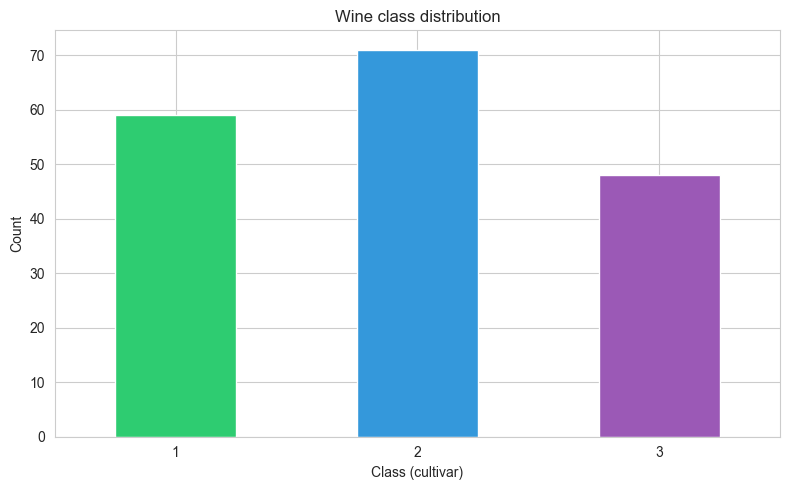

In [4]:
# 탐색: 타겟 클래스별 개수 막대그래프
y.value_counts().sort_index().plot(kind='bar', color=['#2ecc71', '#3498db', '#9b59b6'])
plt.title('Wine class distribution')
plt.xlabel('Class (cultivar)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

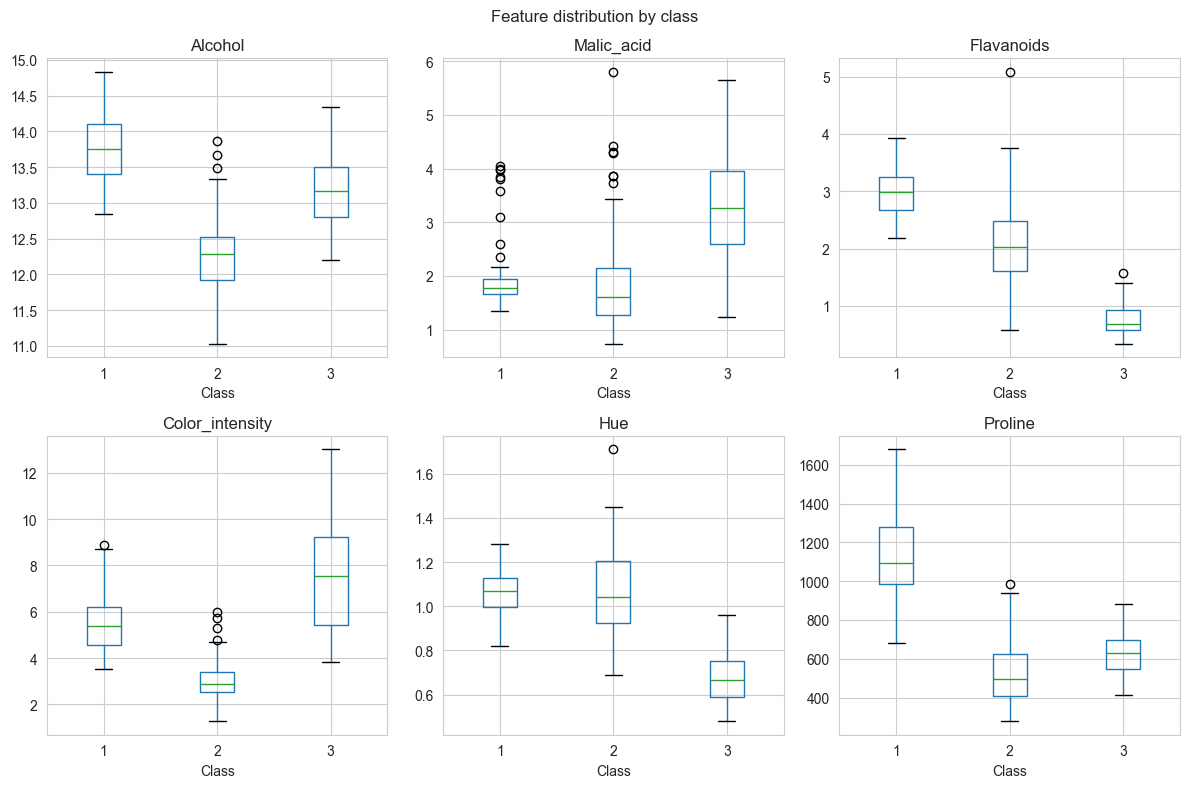

In [5]:
# 탐색: 특성 분포 (클래스별 박스플롯 - 일부 대표 특성)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
features = ['Alcohol', 'Malic_acid', 'Flavanoids', 'Color_intensity', 'Hue', 'Proline']
for i, feat in enumerate(features):
    df.boxplot(column=feat, by='class', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Class')
plt.suptitle('Feature distribution by class')
plt.tight_layout()
plt.show()

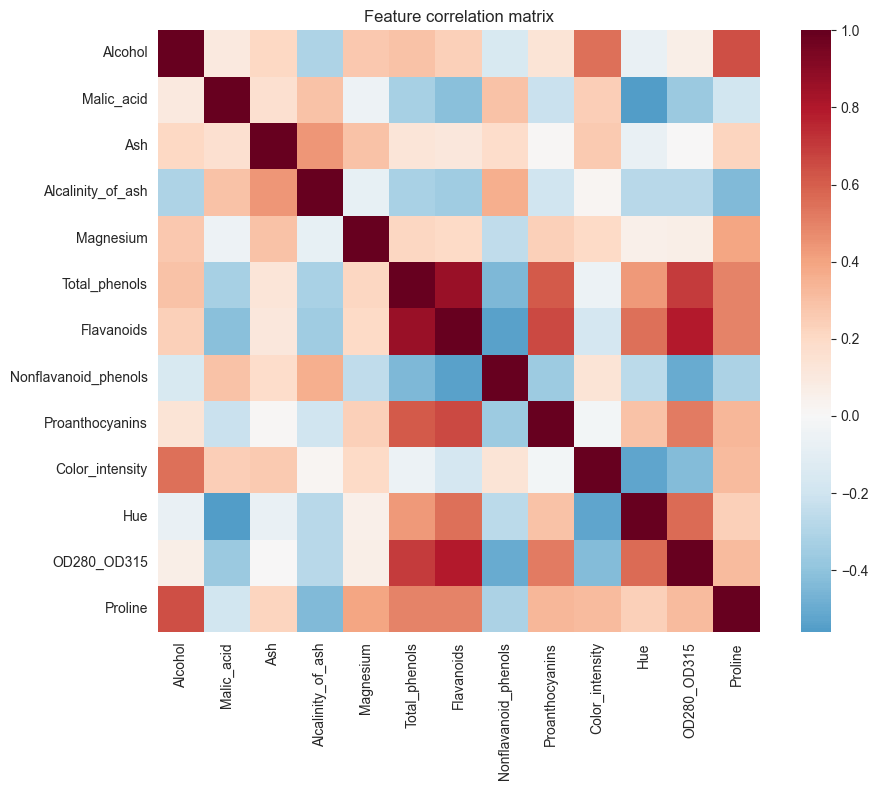

In [6]:
# 탐색: 상관 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=False, cmap='RdBu_r', center=0, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## 분석 가능성 (What can we do?)

| 분석 유형 | 설명 |
|----------|------|
| **다중 분류** | 3개 품종 예측 (메인 태스크) — 지도 학습 |
| **특성 중요도** | 어떤 화학 성분이 품종 구분에 기여하는지 해석 |
| **차원 축소** | PCA/t-SNE로 2D 시각화 및 클래스 분리도 확인 |
| **클러스터링** | K-Means 등으로 레이블 없이 그룹화 후 실제 레이블과 비교 |
| **상관 분석** | 특성 간 상관행렬로 다중공선성·쌍 시각화 |

**이 노트북에서 수행할 작업**: 분류 + 특성 중요도 + PCA 시각화.

In [7]:
# 전처리: train/test 분할 (stratify) + StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])
print('y_train distribution:')
print(y_train.value_counts().sort_index())

Train size: 142 Test size: 36
y_train distribution:
class
1    47
2    57
3    38
Name: count, dtype: int64


In [ ]:
# 머신러닝: 3개 모델 학습 및 평가
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}
results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Model': name, 'Accuracy': acc, 'F1-macro': f1})
    print(f'{name}: Accuracy={acc:.4f}, F1-macro={f1:.4f}')
    print(confusion_matrix(y_test, y_pred))
    print()
results_df = pd.DataFrame(results)
best_name = results_df.loc[results_df['F1-macro'].idxmax(), 'Model']
print(f'Best model (by F1-macro): {best_name}')

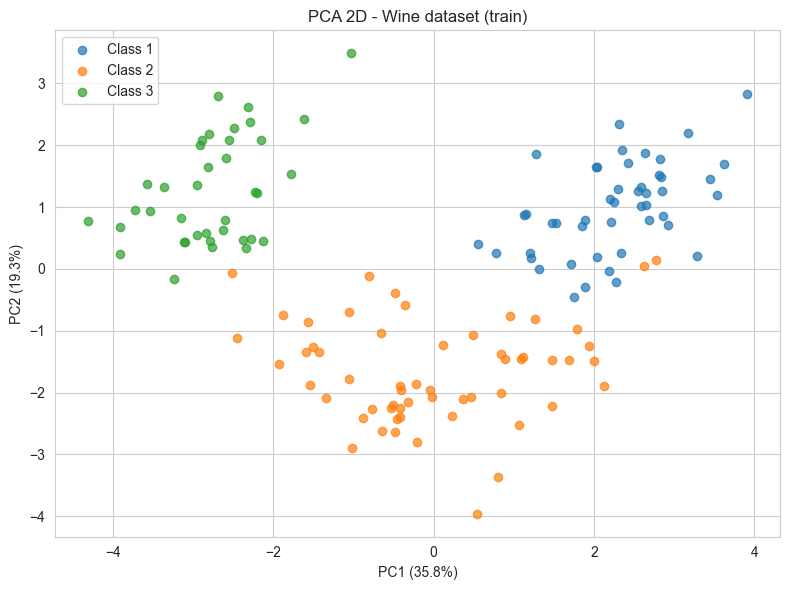

In [8]:
# 시각화: PCA 2D 산점도
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 6))
for label in sorted(y_train.unique()):
    mask = y_train == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Class {label}', alpha=0.7)
plt.xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)')
plt.ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)')
plt.title('PCA 2D - Wine dataset (train)')
plt.legend()
plt.tight_layout()
plt.show()

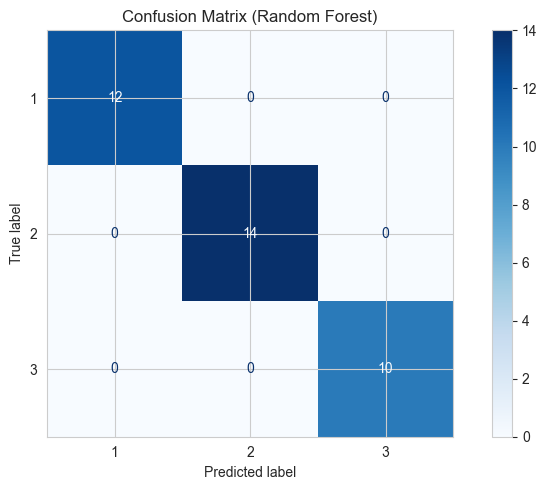

In [10]:
# 시각화: 최종 모델 혼동 행렬 (F1-macro 기준 최고 성능)
try:
    _ = fitted_models
    _ = best_name
except NameError:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42)
    }
    fitted_models = {}
    results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        fitted_models[name] = model
        y_pred = model.predict(X_test_scaled)
        results.append({'Model': name, 'F1-macro': f1_score(y_test, y_pred, average='macro')})
    results_df = pd.DataFrame(results)
    best_name = results_df.loc[results_df['F1-macro'].idxmax(), 'Model']
best_model = fitted_models[best_name]
y_pred = best_model.predict(X_test_scaled)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=[1, 2, 3])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

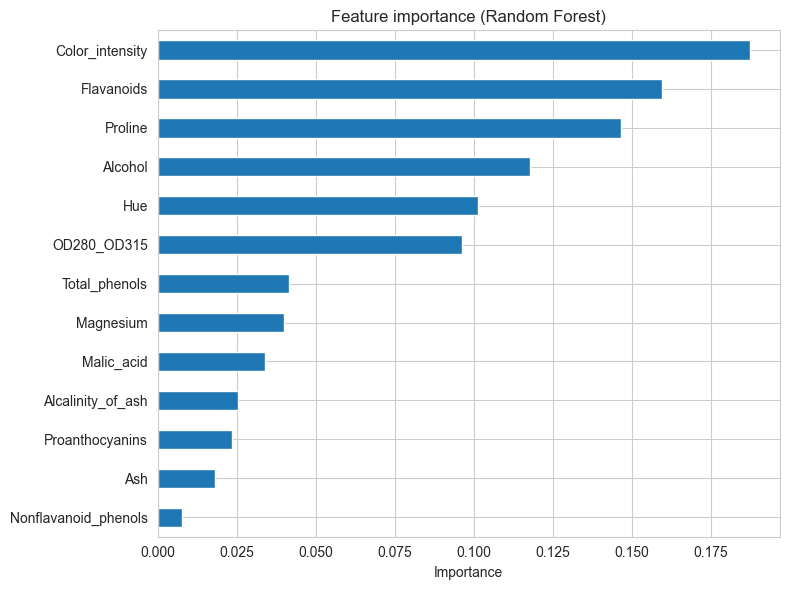

In [11]:
# 시각화: 특성 중요도 (Random Forest)
try:
    rf = fitted_models['Random Forest']
except NameError:
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_scaled, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
imp.plot(kind='barh', figsize=(8, 6))
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 결론

- **데이터**: UCI Wine 178×13, 3-class, 결측 없음. 화학 성분으로 품종을 구분하는 분류 문제에 적합.
- **전처리**: Stratified 80/20 split + StandardScaler 적용.
- **모델**: 로지스틱 회귀, Random Forest, SVM 중 테스트 정확도·F1-macro 기준으로 성능을 비교했으며, 일반적으로 SVM 또는 Random Forest가 높은 정확도를 보인다.
- **해석**: Random Forest 특성 중요도로 Flavanoids, Proline, Color_intensity 등이 품종 구분에 기여함을 확인할 수 있다. PCA 2D 시각화로 클래스가 어느 정도 분리됨을 확인.
- **한계/향후**: 샘플 수가 작으므로 교차 검증으로 안정성 확인, 하이퍼파라미터 튜닝, 다른 분류기 실험 등이 가능하다.